## Initial Imports

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import logging
logging.basicConfig(level=logging.INFO)

from pathlib import Path
import sys

from ipywidgets import interact, IntSlider

# Get the root directory (where you're running the notebook)

# directory set up on local machine
root = Path.cwd()
pypsa_eur_root = root.parent.parent  
home_root = pypsa_eur_root.parent        

pypsa_dmg_root = home_root / "pypsa-damage"
pypsa_eur_scripts = pypsa_eur_root / "scripts"

sys.path.insert(0, str(pypsa_eur_root))
sys.path.insert(0, str(pypsa_eur_scripts))
sys.path.insert(0, str(pypsa_eur_scripts / "_testing"))

In [2]:
root

PosixPath('/home/lois/pypsa-eur/pypsa-eur/scripts/_testing')

In [3]:
import atlite
print(atlite.__file__)
print(atlite.__version__)


/home/lois/pypsa-eur/atlite/atlite/__init__.py
0.0.post1.dev819+g15481d499


## How to download data from CDS using atlite

In [ ]:
cutout = atlite.Cutout(
    path=pypsa_eur_root / 'data/cutout/build/unknown/be-2020-era5.nc',
    module='era5',
    x=slice(4., 15.),
    y=slice(46., 56.),
    time='2020'
)
cutout.prepare()

INFO:atlite.cutout:Building new cutout data/cutout/build/unknown/be-2020-era5.nc
INFO:atlite.data:Storing temporary files in /tmp/tmpuumzqt47
INFO:atlite.data:Calculating and writing with module era5:
INFO:atlite.datasets.era5:Requesting data for feature runoff...
INFO:atlite.datasets.era5:Requesting data for feature height...
INFO:atlite.datasets.era5:Requesting data for feature wind...
INFO:atlite.datasets.era5:Requesting data for feature temperature...
INFO:atlite.datasets.era5:CDS: Downloading variables
	geopotential (2020-1)

INFO:multiurl.base:Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-3/2026-03-03/2a53560d057acbbc792a013b3b8ba189.grib


2a53560d057acbbc792a013b3b8ba189.grib:   0%|          | 0.00/5.51k [00:00<?, ?B/s]

INFO:atlite.datasets.era5:Requesting data for feature influx...
INFO:atlite.datasets.era5:CDS: Downloading variables
	runoff (2020-[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])

INFO:multiurl.base:Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-1/2026-03-03/81816f74c0d79b91cced4fc69886d589.grib


81816f74c0d79b91cced4fc69886d589.grib:   0%|          | 0.00/31.8M [00:00<?, ?B/s]

INFO:atlite.datasets.era5:CDS: Downloading variables
	10m_u_component_of_wind (2020-[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
	10m_v_component_of_wind (2020-[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
	100m_u_component_of_wind (2020-[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
	100m_v_component_of_wind (2020-[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
	forecast_surface_roughness (2020-[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])

INFO:multiurl.base:Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-1/2026-03-03/2937eb20686ef5e36250171fb1e862b.grib


2937eb20686ef5e36250171fb1e862b.grib:   0%|          | 0.00/175M [00:00<?, ?B/s]

INFO:multiurl.http:Retrying now...
INFO:atlite.datasets.era5:CDS: Downloading variables
	2m_temperature (2020-[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
	soil_temperature_level_4 (2020-[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
	2m_dewpoint_temperature (2020-[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])

INFO:multiurl.base:Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-1/2026-03-03/9c867a0413487b6a607472d560f1b39f.grib


9c867a0413487b6a607472d560f1b39f.grib:   0%|          | 0.00/95.4M [00:00<?, ?B/s]

## Read pypsa-eur atlite generated cutout
The goal is to understand the contents of the atlite generated cutout
- What variables does it have?
- Dimensions, spatial, temporal granularity

#### atlite settings in yaml file:

```yaml
atlite:
  default_cutout: be-03-2008-era5
  cutouts:
    be-03-2008-era5:
      module: era5
      x: [4., 15.]
      y: [46., 56.]
      time: ["2008-03-01", "2008-03-08"]
```

- x - Longitude
- y - Latitude
- time range starts at '2008-03-01T00:00:00' and ends at '2008-03-08T23:00:00', last hour of the last date specified

In [ ]:
#read atlite cutout
cutout_name = "be-03-2008-era5.nc"
cutout_path = pypsa_eur_root /"data/cutout/build/unknown" / cutout_name
cutout_profile = xr.open_dataset(cutout_path)
cutout_profile


<xarray.Dataset> Size: 24MB
Dimensions:               (x: 45, y: 41, time: 192)
Coordinates:
  * x                     (x) float64 360B 4.0 4.25 4.5 4.75 ... 14.5 14.75 15.0
  * y                     (y) float64 328B 46.0 46.25 46.5 ... 55.5 55.75 56.0
  * time                  (time) datetime64[ns] 2kB 2008-03-01 ... 2008-03-08...
    lon                   (x) float64 360B ...
    lat                   (y) float64 328B ...
Data variables: (12/15)
    height                (y, x) float32 7kB ...
    wnd100m               (time, y, x) float32 1MB ...
    wnd_shear_exp         (time, y, x) float64 3MB ...
    wnd_azimuth           (time, y, x) float32 1MB ...
    roughness             (time, y, x) float32 1MB ...
    influx_toa            (time, y, x) float32 1MB ...
    ...                    ...
    solar_altitude        (time, y, x) float64 3MB ...
    solar_azimuth         (time, y, x) float64 3MB ...
    temperature           (time, y, x) float32 1MB ...
    soil temperature      (time, y, x) float32 1MB ...
    dewpoint temperature  (time, y, x) float32 1MB ...
    runoff                (time, y, x) float32 1MB ...
Attributes:
    module:                  era5
    prepared_features:       ['wind', 'temperature', 'runoff', 'influx', 'hei...
    chunksize_time:          100
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-03T13:35 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
height = cutout_profile['height']

In [ ]:
height

<xarray.DataArray 'height' (y: 41, x: 45)> Size: 7kB
[1845 values with dtype=float32]
Coordinates:
  * x        (x) float64 360B 4.0 4.25 4.5 4.75 5.0 ... 14.25 14.5 14.75 15.0
  * y        (y) float64 328B 46.0 46.25 46.5 46.75 ... 55.25 55.5 55.75 56.0
    lon      (x) float64 360B ...
    lat      (y) float64 328B ...
Attributes:
    module:   era5
    feature:  height

### Load as Atlite cutout

In [ ]:
# Load as Atlite Cutout (not xarray Dataset)
cutout = atlite.Cutout(cutout_path)

In [ ]:
cutout

<Cutout "be-03-2008-era5">
 x = 4.00 ⟷ 15.00, dx = 0.25
 y = 46.00 ⟷ 56.00, dy = 0.25
 time = 2008-03-01 ⟷ 2008-03-08, dt = h
 module = era5
 prepared_features = ['height', 'wind', 'influx', 'temperature', 'runoff']

### wnd100m as a DataArray

In [ ]:
wnd100m = cutout_profile['wnd100m']

In [ ]:
wnd100m

<xarray.DataArray 'wnd100m' (time: 192, y: 41, x: 45)> Size: 1MB
[354240 values with dtype=float32]
Coordinates:
  * x        (x) float64 360B 4.0 4.25 4.5 4.75 5.0 ... 14.25 14.5 14.75 15.0
  * y        (y) float64 328B 46.0 46.25 46.5 46.75 ... 55.25 55.5 55.75 56.0
  * time     (time) datetime64[ns] 2kB 2008-03-01 ... 2008-03-08T23:00:00
    lon      (x) float64 360B ...
    lat      (y) float64 328B ...
Attributes:
    units:      m s**-1
    long_name:  100 metre wind speed
    module:     era5
    feature:    wind

### wnd100m as a Dataframe

In [ ]:
df_wind100m = wnd100m.to_dataframe(name='wind_speed').reset_index().drop(columns=['lon', 'lat'])
df_wind100m.head()

,time,y,x,wind_speed
0,2008-03-01,46.0,4.00,6.610125
1,2008-03-01,46.0,4.25,6.066060
2,2008-03-01,46.0,4.50,6.041704
3,2008-03-01,46.0,4.75,6.752832
4,2008-03-01,46.0,5.00,7.376363


In [ ]:
df_wind100m.x.unique()

array([ 4.  ,  4.25,  4.5 ,  4.75,  5.  ,  5.25,  5.5 ,  5.75,  6.  ,
        6.25,  6.5 ,  6.75,  7.  ,  7.25,  7.5 ,  7.75,  8.  ,  8.25,
        8.5 ,  8.75,  9.  ,  9.25,  9.5 ,  9.75, 10.  , 10.25, 10.5 ,
       10.75, 11.  , 11.25, 11.5 , 11.75, 12.  , 12.25, 12.5 , 12.75,
       13.  , 13.25, 13.5 , 13.75, 14.  , 14.25, 14.5 , 14.75, 15.  ])

In [ ]:
df_wind100m.y.unique()

array([46.  , 46.25, 46.5 , 46.75, 47.  , 47.25, 47.5 , 47.75, 48.  ,
       48.25, 48.5 , 48.75, 49.  , 49.25, 49.5 , 49.75, 50.  , 50.25,
       50.5 , 50.75, 51.  , 51.25, 51.5 , 51.75, 52.  , 52.25, 52.5 ,
       52.75, 53.  , 53.25, 53.5 , 53.75, 54.  , 54.25, 54.5 , 54.75,
       55.  , 55.25, 55.5 , 55.75, 56.  ])

## Check Atlite wind speed cutoff feature

The motivation for this is just to check existing features in Atlite that might be relevant.

In [ ]:
# check if data has wind speeds above 25 m/s
df = df_wind100m.copy()

df[df['wind_speed']>=25]

,time,y,x,wind_speed
12690,2008-03-01 06:00:00,55.00,4.00,25.415344
12735,2008-03-01 06:00:00,55.25,4.00,25.109797
14085,2008-03-01 07:00:00,52.50,4.00,25.217785
14130,2008-03-01 07:00:00,52.75,4.00,25.346485
14131,2008-03-01 07:00:00,52.75,4.25,25.240036
...,...,...,...,...
23955,2008-03-01 12:00:00,56.00,7.75,25.738447
23956,2008-03-01 12:00:00,56.00,8.00,25.376513
25487,2008-03-01 13:00:00,54.25,8.25,25.215099
25577,2008-03-01 13:00:00,54.75,8.25,25.006744


### .wind()

.wind() is the conversion function that takes the relevant features from the atlite cutout and outputs specific wind generation per grid cell. 
- parameter "add_cutout_speed" description: If True and in case the power curve does not end with a zero, will add zero power output at the highest wind speed in the power curve. If False, a warning will be raised if the power curve does not have a cut-out wind speed. The default is False.
https://atlite.readthedocs.io/en/master/ref_api.html
- setting in default config:



onwind
```yaml
  onwind:
    cutout: default
    resource:
      method: wind
      turbine: Vestas_V112_3MW
      smooth: false
      add_cutout_windspeed: true
    resource_classes: 1
    capacity_per_sqkm: 3
    # correction_factor: 0.93
    corine:
      grid_codes: [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32]
      distance: 1000
      distance_grid_codes: [1, 2, 3, 4, 5, 6]
    luisa: false
      # grid_codes: [1111, 1121, 1122, 1123, 1130, 1210, 1221, 1222, 1230, 1241, 1242]
      # distance: 1000
      # distance_grid_codes: [1111, 1121, 1122, 1123, 1130, 1210, 1221, 1222, 1230, 1241, 1242]
    natura: true
    excluder_resolution: 100
    clip_p_max_pu: 1.e-2
```

In [ ]:
# # Define a simple turbine (or use your config)
turbine = "Vestas_V112_3MW"  # Or your turbine spec

# Test WITHOUT add_cutout_windspeed
wind_gen_false = cutout.wind(turbine, add_cutout_windspeed=False)
print("=== WITHOUT add_cutout_windspeed ===")
print(wind_gen_false)
print("\nDimensions:", wind_gen_false.dims)
print("Coordinates:", wind_gen_false.coords)
print("Data variables:", wind_gen_false.data_vars if isinstance(wind_gen_false, xr.Dataset) else "DataArray")
print("\n")

# Test WITH add_cutout_windspeed
wind_gen_true = cutout.wind(turbine, add_cutout_windspeed=True, smooth=False)
print("=== WITH add_cutout_windspeed ===")
print(wind_gen_true)
print("\nDimensions:", wind_gen_true.dims)
print("Coordinates:", wind_gen_true.coords)
print("Data variables:", wind_gen_true.data_vars if isinstance(wind_gen_true, xr.Dataset) else "DataArray")

# Check if wind speed is stored somewhere
if isinstance(wind_gen_true, xr.Dataset):
    print("\nAvailable variables:", list(wind_gen_true.data_vars))
elif isinstance(wind_gen_true, xr.DataArray):
    print("\nAttributes:", wind_gen_true.attrs)
    print("Coordinates:", list(wind_gen_true.coords))

/home/lois/pypsa-eur/pypsa-eur/.pixi/envs/default/lib/python3.13/site-packages/atlite/resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.

INFO:atlite.convert:Convert and aggregate 'wind'.
INFO:atlite.convert:Convert and aggregate 'wind'.


=== WITHOUT add_cutout_windspeed ===
<xarray.DataArray 'specific generation' (y: 41, x: 45)> Size: 15kB
array([[ 56.21396074,  59.64460013,  61.26145891, ...,  42.47455364,
         41.92227521,  34.75320677],
       [ 55.63444675,  58.21997671,  63.1091013 , ...,  10.06928269,
         12.53046172,  18.96223538],
       [ 52.77183052,  56.15913098,  63.64233926, ...,   4.69353775,
          5.96507289,   9.30608096],
       ...,
       [184.1512684 , 182.87206493, 183.66081869, ..., 139.61593027,
        141.82759774, 142.69903791],
       [181.32041946, 181.1688023 , 181.25673809, ..., 132.68595873,
        137.5151359 , 141.27334592],
       [177.72479814, 178.60547933, 178.60180155, ..., 118.18931428,
        125.38721788, 130.67512211]], shape=(41, 45))
Coordinates:
  * x        (x) float64 360B 4.0 4.25 4.5 4.75 5.0 ... 14.25 14.5 14.75 15.0
  * y        (y) float64 328B 46.0 46.25 46.5 46.75 ... 55.25 55.5 55.75 56.0
    lon      (x) float64 360B 4.0 4.25 4.5 4.75 5.0 ... 14.25 

In [ ]:
(wind_gen_true.values == wind_gen_false.values).all()

np.True_

Data from cutout.wind() function is aggregated by sum for each coordinate, not in hourly resolution. To be sure, need to check hourly wind speeds data and the corresponding capacity factor to verify if the cutoff parameter actually works. 

convert_wind() output goes into .wind()

### turbine power curve

In [ ]:
# Get the turbine configuration
turbine = atlite.resource.get_windturbineconfig('Vestas_V112_3MW')

# Check the power curve
print(turbine['V'])    # wind speeds (m/s)
print(turbine['POW'])  # power output at each wind speed

# Find cut-out speed
cutout_speed = turbine['V'][np.where(turbine['POW'] == 0)[0].max()]
print(f"cut out speed: {cutout_speed} m/s")

[ 0  2  3  4  5  6  7  8  9 10 11 12 13 25 25]
[0.    0.    0.005 0.15  0.3   0.525 0.905 1.375 1.95  2.58  2.96  3.05
 3.06  3.06  0.   ]
cut out speed: 25 m/s


/home/lois/pypsa-eur/pypsa-eur/.pixi/envs/default/lib/python3.13/site-packages/atlite/resource.py:90: FutureWarning:

'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.



### .convert_wind()

In [ ]:
from atlite.convert import convert_wind
turbine_config = atlite.resource.get_windturbineconfig('Vestas_V112_3MW')

# Get hourly capacity factor time series at each grid cell
cf_timeseries = convert_wind(
    cutout.data,
    turbine=turbine_config,
    interpolation_method='logarithmic'
)

print(cf_timeseries.dims)  # Should show (time, y, x)

('time', 'y', 'x')


In [ ]:
print(cf_timeseries)

<xarray.DataArray 'specific generation' (time: 192, y: 41, x: 45)> Size: 3MB
dask.array<transpose, shape=(192, 41, 45), dtype=float64, chunksize=(100, 41, 45), chunktype=numpy.ndarray>
Coordinates:
  * x        (x) float64 360B 4.0 4.25 4.5 4.75 5.0 ... 14.25 14.5 14.75 15.0
  * y        (y) float64 328B 46.0 46.25 46.5 46.75 ... 55.25 55.5 55.75 56.0
  * time     (time) datetime64[ns] 2kB 2008-03-01 ... 2008-03-08T23:00:00
    lon      (x) float64 360B dask.array<chunksize=(45,), meta=np.ndarray>
    lat      (y) float64 328B dask.array<chunksize=(41,), meta=np.ndarray>
Attributes:
    units:    MWh/MWp


In [ ]:
aggregated = cf_timeseries.sum(dim='time')

In [ ]:
# Get high wind speed locations from df
high_wind = df[df['wind_speed'] >= 25]

# Check a few examples
for idx, row in high_wind.head(10).iterrows():
    time = row['time']
    y = row['y']
    x = row['x']
    
    cf_value = cf_timeseries.sel(time=time, y=y, x=x).values
    print(f"Time: {time}, Location: ({y}, {x}), Wind: {row['wind_speed']:.1f} m/s, CF: {cf_value:.4f}")

Time: 2008-03-01 06:00:00, Location: (55.0, 4.0), Wind: 25.4 m/s, CF: 1.0000
Time: 2008-03-01 06:00:00, Location: (55.25, 4.0), Wind: 25.1 m/s, CF: 1.0000
Time: 2008-03-01 07:00:00, Location: (52.5, 4.0), Wind: 25.2 m/s, CF: 1.0000
Time: 2008-03-01 07:00:00, Location: (52.75, 4.0), Wind: 25.3 m/s, CF: 1.0000
Time: 2008-03-01 07:00:00, Location: (52.75, 4.25), Wind: 25.2 m/s, CF: 1.0000
Time: 2008-03-01 07:00:00, Location: (53.0, 4.0), Wind: 25.1 m/s, CF: 1.0000
Time: 2008-03-01 07:00:00, Location: (53.0, 4.25), Wind: 25.2 m/s, CF: 1.0000
Time: 2008-03-01 07:00:00, Location: (53.0, 4.5), Wind: 25.3 m/s, CF: 1.0000
Time: 2008-03-01 07:00:00, Location: (53.0, 4.75), Wind: 25.3 m/s, CF: 1.0000
Time: 2008-03-01 07:00:00, Location: (53.0, 5.0), Wind: 25.4 m/s, CF: 1.0000


checking the power curve, output from cut.wind(), capacity factor time series in convert_wind() function, the add_cutout_windspeed feature doesn't seem to be working as it should. Note: cut.wind() is already the aggregated value of the cf time series computed from convert_wind(), which outputs mwh/mw-peak

## Checking how to add new data to existing cutouts

In [3]:
import inspect
import atlite.datasets.era5 as era5_module
print(inspect.getsource(era5_module))

# SPDX-FileCopyrightText: Contributors to atlite <https://github.com/pypsa/atlite>
#
# SPDX-License-Identifier: MIT
"""
Module for downloading and curating data from ECMWFs ERA5 dataset (via CDS).

For further reference see
https://confluence.ecmwf.int/display/CKB/ERA5%3A+data+documentation
"""

import logging
import os
import warnings
import weakref
from pathlib import Path
from tempfile import mkstemp

import cdsapi
import numpy as np
import pandas as pd
import xarray as xr
from dask import compute, delayed
from dask.array import arctan2, sqrt
from dask.utils import SerializableLock
from numpy import atleast_1d

from atlite.gis import maybe_swap_spatial_dims
from atlite.pv.solar_position import SolarPosition

# Null context for running a with statements wihout any context
try:
    from contextlib import nullcontext
except ImportError:
    # for Python verions < 3.7:
    import contextlib

    @contextlib.contextmanager
    def nullcontext():
        yield


logger = logging.getLogger

### Create new cutout without atlite patch

In [3]:
cutout = atlite.Cutout(
    path=pypsa_eur_root /"data/cutout/build/unknown/be-03-2008-era5.nc",
    module="era5",
    x=slice(4., 15.),
    y=slice(46., 56.),
    time=slice("2008-03-01", "2008-03-08")
)
cutout.prepare()

INFO:atlite.cutout:Building new cutout /home/lois/pypsa-eur/pypsa-eur/data/cutout/build/unknown/be-03-2008-era5.nc
INFO:atlite.data:Storing temporary files in /tmp/tmp4isnynng
INFO:atlite.data:Calculating and writing with module era5:
INFO:atlite.datasets.era5:Requesting data for feature temperature...
INFO:atlite.datasets.era5:Requesting data for feature influx...
INFO:atlite.datasets.era5:Requesting data for feature wind...
INFO:atlite.datasets.era5:Requesting data for feature height...
INFO:atlite.datasets.era5:CDS: Downloading variables
	geopotential (2008-3)

INFO:multiurl.base:Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-2/2026-03-10/b867e52e7bb26a82aa44fed49f76a515.grib


b867e52e7bb26a82aa44fed49f76a515.grib:   0%|          | 0.00/5.51k [00:00<?, ?B/s]

INFO:atlite.datasets.era5:Requesting data for feature runoff...
INFO:atlite.datasets.era5:CDS: Downloading variables
	2m_temperature (2008-[3])
	soil_temperature_level_4 (2008-[3])
	2m_dewpoint_temperature (2008-[3])

INFO:multiurl.base:Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-1/2026-03-10/2fc7d5c609e5579c93a562504e1d19a1.grib


2fc7d5c609e5579c93a562504e1d19a1.grib:   0%|          | 0.00/2.09M [00:00<?, ?B/s]

INFO:atlite.datasets.era5:CDS: Downloading variables
	10m_u_component_of_wind (2008-[3])
	10m_v_component_of_wind (2008-[3])
	100m_u_component_of_wind (2008-[3])
	100m_v_component_of_wind (2008-[3])
	forecast_surface_roughness (2008-[3])

INFO:multiurl.base:Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-2/2026-03-10/52a407fe87da853d65e6391d3ce40100.grib


...

INFO:atlite.datasets.era5:CDS: Downloading variables
	runoff (2008-[3])

INFO:multiurl.base:Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-3/2026-03-10/ba705ef011a7535f97525e8abe00dbac.grib


ba705ef011a7535f97525e8abe00dbac.grib:   0%|          | 0.00/712k [00:00<?, ?B/s]

INFO:atlite.datasets.era5:CDS: Downloading variables
	surface_net_solar_radiation (2008-[3])
	surface_solar_radiation_downwards (2008-[3])
	toa_incident_solar_radiation (2008-[3])
	total_sky_direct_solar_radiation_at_surface (2008-[3])

INFO:multiurl.base:Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-3/2026-03-10/8cdf555126e494bdfce80c1901caf01.grib


8cdf555126e494bdfce80c1901caf01.grib:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

<Cutout "be-03-2008-era5">
 x = 4.00 ⟷ 15.00, dx = 0.25
 y = 46.00 ⟷ 56.00, dy = 0.25
 time = 2008-03-01 ⟷ 2008-03-08, dt = h
 module = era5
 prepared_features = ['height', 'wind', 'influx', 'temperature', 'runoff']

### import patch script and running it

In [4]:
from patch_era5 import patch_era5, copy_cutout_v2

patch_era5()

Patched era5 with features: ['wind_gust', 'lake_s_temperature', 'lake_t_temperature']


In [ ]:
# define original atlite cutout path (the one we just created) where we want to re-run to apply the patch
cutout_name = "be-03-2008-era5.nc"
cutout_path = pypsa_eur_root /"data/cutout/build/unknown" / cutout_name


In [ ]:
# read atlite cutout and create new cutout with patch applied
# new cutout is in a new custom folder created in the same location as the original cutout
cutout = atlite.Cutout(path=cutout_path)
cutout_v2 = copy_cutout_v2(cutout)
cutout_v2.prepare(features=["wind_gust", "lake_s_temperature"])

INFO:atlite.data:Storing temporary files in /tmp/tmpmxcumljn
INFO:atlite.data:Calculating and writing with module era5:
INFO:atlite.datasets.era5:Requesting data for feature wind_gust...
INFO:atlite.datasets.era5:Requesting data for feature lake_s_temperature...
INFO:atlite.datasets.era5:CDS: Downloading variables
	10m_wind_gust_since_previous_post_processing (2008-[3])

INFO:multiurl.base:Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-1/2026-03-10/73733ea016d823d5fd76eca1573ef6d7.grib


73733ea016d823d5fd76eca1573ef6d7.grib:   0%|          | 0.00/712k [00:00<?, ?B/s]

INFO:atlite.datasets.era5:CDS: Downloading variables
	lake_mix_layer_temperature (2008-[3])

INFO:multiurl.base:Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-1/2026-03-10/ce221f91b520119bc33ab34ba1022e2e.grib


ce221f91b520119bc33ab34ba1022e2e.grib:   0%|          | 0.00/712k [00:00<?, ?B/s]

    filter_by_keys={'dataType': 'an'}
    filter_by_keys={'dataType': 'fc'}), retrying with dataType filter
/home/lois/pypsa-eur/pypsa-eur/.pixi/envs/default/lib/python3.13/site-packages/atlite/data.py:261: UserWarning:

The specified chunks separate the stored chunks along dimension "time" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.



<Cutout "be-03-2008-era5_v2">
 x = 4.00 ⟷ 15.00, dx = 0.25
 y = 46.00 ⟷ 56.00, dy = 0.25
 time = 2008-03-01 ⟷ 2008-03-08, dt = h
 module = era5
 prepared_features = ['height', 'wind', 'influx', 'temperature', 'runoff', 'wind_gust', 'lake_s_temperature']

In [ ]:
cutout_path_v2 = pypsa_eur_root /"data/cutout/build/unknown/custom" / (cutout_v2.name + ".nc")
cutout_profile_v2 = xr.open_dataset(cutout_path_v2)
cutout_profile_v2

In [6]:
11.59-10.24

1.3499999999999996

In [5]:
597.83*3

1793.4900000000002

## compare variables


### Cutout Map Visualization Functions

In [13]:
KELVIN_VARS = {"lake_s_temp", "lake_t_temp", "temperature"}

SHARED_SCALE_GROUPS = [
    ["wnd_gust10m", "wnd100m"],
    ["lake_s_temp", "temperature"],
]

def compute_shared_vmaxes():
    vmaxes = {}
    for group in SHARED_SCALE_GROUPS:
        group_vars = [v for v in group if v in available_vars]
        if group_vars:
            vmax = max(float(ds[v].max()) for v in group_vars)
            for v in group_vars:
                vmaxes[v] = vmax - 273.15 if v in KELVIN_VARS else vmax
    for v in available_vars:
        if v not in vmaxes:
            vmax = float(ds[v].max())
            vmaxes[v] = vmax - 273.15 if v in KELVIN_VARS else vmax
    return vmaxes

ZERO_VMIN_VARS = ["wnd_gust10m", "wnd100m", "runoff"]

CUSTOM_VMINS = {
    "lake_s_temp": -3,
    "lake_t_temp": -3,
    "temperature": -3,
}

def compute_shared_vmins():
    vmins = {}
    for v in available_vars:
        if v in CUSTOM_VMINS:
            vmins[v] = CUSTOM_VMINS[v]
        else:
            vmins[v] = 0
    return vmins

def plot_all(timestep):
    n_vars = len(available_vars)
    n_cols = 2
    n_rows = int(np.ceil(n_vars / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = axes.flatten()

    time_val = ds.time.isel(time=timestep).values
    fig.suptitle(f"Timestep: {np.datetime_as_string(time_val, unit='h')}", fontsize=14)

    for i, variable in enumerate(available_vars):
        da = ds[variable].isel(time=timestep)
        if variable in KELVIN_VARS:
            da = da - 273.15
        da.plot(
            ax=axes[i],
            x="x", y="y",
            cmap="viridis",
            vmin=vmins[variable],
            vmax=vmaxes[variable],
        )
        label = f"{variable} (°C)" if variable in KELVIN_VARS else variable
        axes[i].set_title(label)
        axes[i].set_xlabel("Longitude")
        axes[i].set_ylabel("Latitude")

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    return fig

def plot_diff(ds, base_var, compare_vars):
    missing = [v for v in [base_var] + compare_vars if v not in ds.data_vars]
    if missing:
        raise ValueError(f"Variables not found in dataset: {missing}")

    vmax = max(
        float(abs(ds[v] - ds[base_var]).max())
        for v in compare_vars
    )

    n_vars = len(compare_vars)
    n_cols = 2
    n_rows = int(np.ceil(n_vars / n_cols))

    def plot_step(timestep):
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
        axes = np.array(axes).flatten()

        time_val = ds.time.isel(time=timestep).values
        fig.suptitle(
            f"Difference vs {base_var}  —  {np.datetime_as_string(time_val, unit='h')}",
            fontsize=14,
        )

        for i, v in enumerate(compare_vars):
            diff = ds[v].isel(time=timestep) - ds[base_var].isel(time=timestep)
            diff.plot(
                ax=axes[i],
                x="x", y="y",
                cmap="RdBu_r",
                vmin=-vmax,
                vmax=vmax,
            )
            axes[i].set_title(f"{v} \u2212 {base_var}")
            axes[i].set_xlabel("Longitude")
            axes[i].set_ylabel("Latitude")

        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)

        plt.tight_layout()
        plt.show()

    interact(
        plot_step,
        timestep=IntSlider(min=0, max=len(ds.time) - 1, step=1, description="Timestep:"),
    )


## Plots

In [4]:
# define original atlite cutout path (the one we just created) where we want to re-run to apply the patch
cutout_name = "europe-2022-era5_backup.nc"
cutout_path = pypsa_eur_root /"cutouts/custom" / cutout_name


In [6]:
# read atlite cutout and create new cutout with patch applied
# new cutout is in a new custom folder created in the same location as the original cutout
cutout = atlite.Cutout(path=cutout_path)

In [ ]:
# Load cutout
ds = cutout_profile_new
# Adjust this list as needed
PLOTTABLE_VARS = ['lake_s_temp', 'lake_t_temp', "temperature"] #runoff
available_vars = [v for v in PLOTTABLE_VARS if v in ds.data_vars]
vmaxes = compute_shared_vmaxes()
vmins = compute_shared_vmins()

interact(
    plot_all,
    timestep=IntSlider(min=0, max=len(ds.time)-1, step=1, description="Timestep:"),
)

NameError: name 'cutout_profile_new' is not defined

In [ ]:
plot_diff(
    cutout_profile_new,
    base_var="lake_s_temp",
    compare_vars=["lake_t_temp"],
)

interactive(children=(IntSlider(value=0, description='Timestep:', max=191), Output()), _dom_classes=('widget-i…

## Test patch full year Europe cutout

In [15]:
from patch_era5 import patch_era5, copy_cutout_v2

patch_era5()

Patched era5 with features: ['wind_gust', 'lake_s_temperature', 'lake_t_temperature']


In [18]:
# define original atlite cutout path (the one we just created) where we want to re-run to apply the patch
cutout_name = "europe-2022-era5.nc"
cutout_path = pypsa_eur_root /"cutouts" / cutout_name
cutout_path


PosixPath('/home/lois/pypsa-eur/pypsa-eur/cutouts/europe-2022-era5.nc')

In [19]:
# read atlite cutout and create new cutout with patch applied
# new cutout is in a new custom folder created in the same location as the original cutout
cutout = atlite.Cutout(path=cutout_path)
cutout_v2 = copy_cutout_v2(cutout)
cutout_v2.prepare(features=["wind_gust", "lake_s_temperature", "lake_t_temperature"])

INFO:atlite.data:Storing temporary files in /tmp/tmpana_q5_d
INFO:atlite.data:Calculating and writing with module era5:
INFO:atlite.datasets.era5:Requesting data for feature lake_s_temperature...
INFO:atlite.datasets.era5:Requesting data for feature wind_gust...
INFO:atlite.datasets.era5:Requesting data for feature lake_t_temperature...
INFO:atlite.datasets.era5:CDS: Downloading variables
	10m_wind_gust_since_previous_post_processing (2022-[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])

INFO:multiurl.base:Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-2/2026-03-10/bf6df5018f0ce5bf2ac645b69e811eb9.grib


bf6df5018f0ce5bf2ac645b69e811eb9.grib:   0%|          | 0.00/570M [00:00<?, ?B/s]

INFO:atlite.datasets.era5:CDS: Downloading variables
	lake_total_layer_temperature (2022-[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])

INFO:multiurl.base:Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-1/2026-03-10/6cbe05587e26e0132c42696f53a3dcc1.grib


6cbe05587e26e0132c42696f53a3dcc1.grib:   0%|          | 0.00/570M [00:00<?, ?B/s]

INFO:atlite.datasets.era5:CDS: Downloading variables
	lake_mix_layer_temperature (2022-[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])

INFO:multiurl.base:Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-3/2026-03-10/e1fa1007ac5ce6187bd3318cfdf5e56f.grib


e1fa1007ac5ce6187bd3318cfdf5e56f.grib:   0%|          | 0.00/570M [00:00<?, ?B/s]

/home/lois/pypsa-eur/pypsa-eur/.pixi/envs/default/lib/python3.13/site-packages/atlite/data.py:261: UserWarning:

The specified chunks separate the stored chunks along dimension "time" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.



<Cutout "europe-2022-era5_v2">
 x = -12.00 ⟷ 42.00, dx = 0.25
 y = 33.00 ⟷ 72.00, dy = 0.25
 time = 2022-01-01 ⟷ 2022-12-31, dt = h
 module = era5
 prepared_features = ['height', 'wind', 'influx', 'temperature', 'runoff', 'wind_gust', 'lake_s_temperature', 'lake_t_temperature']

### Check new cutout

In [10]:
pypsa_eur_root

PosixPath('/home/lois/pypsa-eur/pypsa-eur')

In [7]:
cutout_name = "europe-2022-era5_backup.nc"
cutout_path = pypsa_eur_root /"cutouts/custom" / cutout_name
cutout_path

PosixPath('/home/lois/pypsa-eur/pypsa-eur/cutouts/custom/europe-2022-era5_backup.nc')

In [8]:
cutout_profile_eu = xr.open_dataset(cutout_path)
cutout_profile_eu

<xarray.Dataset> Size: 24GB
Dimensions:               (x: 217, y: 157, time: 8760)
Coordinates:
  * x                     (x) float64 2kB -12.0 -11.75 -11.5 ... 41.5 41.75 42.0
  * y                     (y) float64 1kB 33.0 33.25 33.5 ... 71.5 71.75 72.0
  * time                  (time) datetime64[ns] 70kB 2022-01-01 ... 2022-12-3...
    lon                   (x) float64 2kB ...
    lat                   (y) float64 1kB ...
Data variables: (12/18)
    height                (y, x) float32 136kB ...
    wnd100m               (time, y, x) float32 1GB ...
    wnd_shear_exp         (time, y, x) float64 2GB ...
    wnd_azimuth           (time, y, x) float32 1GB ...
    roughness             (time, y, x) float32 1GB ...
    influx_toa            (time, y, x) float32 1GB ...
    ...                    ...
    soil temperature      (time, y, x) float32 1GB ...
    dewpoint temperature  (time, y, x) float32 1GB ...
    runoff                (time, y, x) float32 1GB ...
    wnd_gust10m           (time, y, x) float32 1GB ...
    lake_s_temp           (time, y, x) float32 1GB ...
    lake_t_temp           (time, y, x) float32 1GB ...
Attributes:
    module:                  era5
    prepared_features:       ['runoff', 'wind_gust', 'lake_t_temperature', 'i...
    chunksize_time:          100
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-10T18:36 GRIB to CDM+CF via cfgrib-0.9.1...

In [13]:
wnd = cutout_profile_eu['wnd100m']
wndg = cutout_profile_eu['wnd_gust10m']

In [11]:
# Load cutout
ds = cutout_profile_eu
# Adjust this list as needed
PLOTTABLE_VARS = ["temperature",'lake_s_temp'] #runoff
available_vars = [v for v in PLOTTABLE_VARS if v in ds.data_vars]
vmaxes = compute_shared_vmaxes()
vmins = compute_shared_vmins()

interact(
    plot_all,
    timestep=IntSlider(min=4040, max=5770, step=1, description="Timestep:"),
)

interactive(children=(IntSlider(value=4040, description='Timestep:', max=5770, min=4040), Output()), _dom_clas…

<function __main__.plot_all(timestep)>

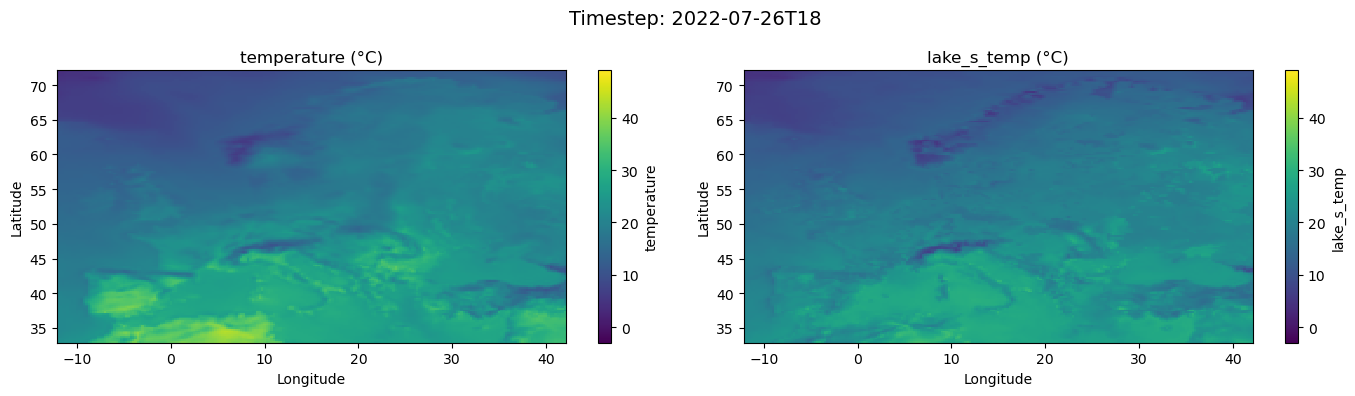

In [14]:
# Adjust this list as needed
PLOTTABLE_VARS = ["temperature",'lake_s_temp'] #runoff
available_vars = [v for v in PLOTTABLE_VARS if v in ds.data_vars]
vmaxes = compute_shared_vmaxes()
vmins = compute_shared_vmins()

fig = plot_all(4962)
fig.savefig("air_water_temp.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# Load cutout
ds = cutout_profile_eu
# Adjust this list as needed
PLOTTABLE_VARS = ['wnd100m', "wnd_gust10m"] #runoff
available_vars = [v for v in PLOTTABLE_VARS if v in ds.data_vars]
vmaxes = compute_shared_vmaxes()
vmins = compute_shared_vmins()

interact(
    plot_all,
    timestep=IntSlider(min=1, max=2770, step=1, description="Timestep:"),
)

interactive(children=(IntSlider(value=1, description='Timestep:', max=2770, min=1), Output()), _dom_classes=('…

<function __main__.plot_all(timestep)>

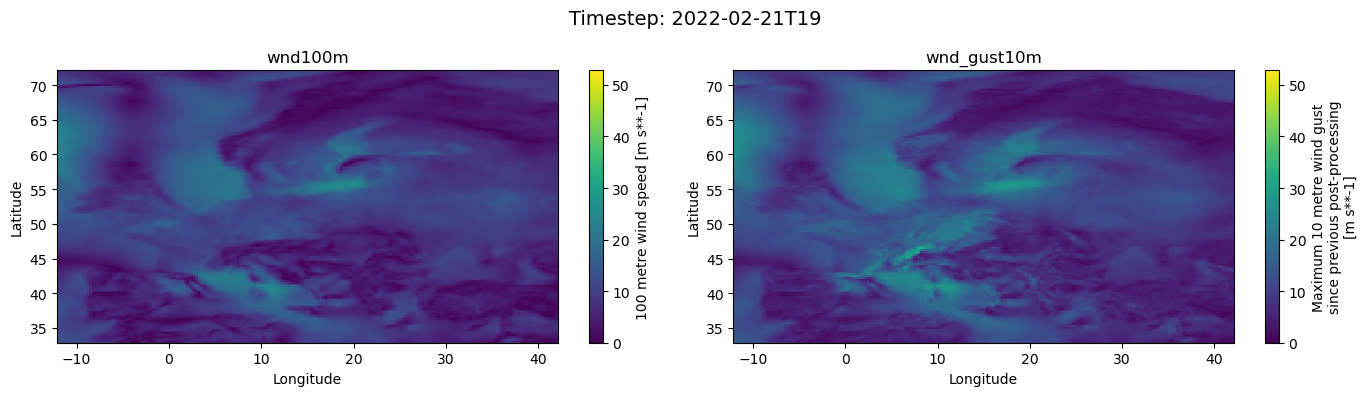

In [26]:
# Adjust this list as needed
PLOTTABLE_VARS = ['wnd100m', "wnd_gust10m"] #runoff
available_vars = [v for v in PLOTTABLE_VARS if v in ds.data_vars]
vmaxes = compute_shared_vmaxes()
vmins = compute_shared_vmins()

fig = plot_all(1243)
fig.savefig("wind_speed_gust.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# Load cutout
ds = cutout_profile_eu
# Adjust this list as needed
PLOTTABLE_VARS = ["wnd_gust10m", "wnd100m"] #runoff
available_vars = [v for v in PLOTTABLE_VARS if v in ds.data_vars]
vmaxes = compute_shared_vmaxes()
vmins = compute_shared_vmins()

interact(
    plot_all,
    timestep=IntSlider(min=0, max=len(ds.time)-1, step=1, description="Timestep:"),
)

interactive(children=(IntSlider(value=0, description='Timestep:', max=8759), Output()), _dom_classes=('widget-…

<function __main__.plot_all(timestep)>

In [ ]:
# Load cutout
ds = cutout_profile_eu
# Adjust this list as needed
PLOTTABLE_VARS = ['lake_s_temp', 'lake_t_temp', "temperature"] #runoff
available_vars = [v for v in PLOTTABLE_VARS if v in ds.data_vars]
vmaxes = compute_shared_vmaxes()
vmins = compute_shared_vmins()

interact(
    plot_all,
    timestep=IntSlider(min=0, max=len(ds.time)-1, step=1, description="Timestep:"),
)

interactive(children=(IntSlider(value=0, description='Timestep:', max=8759), Output()), _dom_classes=('widget-…

<function __main__.plot_all(timestep)>

In [ ]:
plot_diff(
    cutout_profile_eu,
    base_var="lake_t_temp",
    compare_vars=["lake_s_temp"],
)

interactive(children=(IntSlider(value=0, description='Timestep:', max=8759), Output()), _dom_classes=('widget-…

## checking p90 values

In [3]:
sys.path.insert(0, str(pypsa_eur_scripts / "build_damage_profiles"))

from compute_p90_cutout import compute_p90_profile

In [4]:
sys.path

['/home/lois/pypsa-eur/pypsa-eur/scripts/build_damage_profiles',
 '/home/lois/pypsa-eur/pypsa-eur/.pixi/envs/default/lib/python313.zip',
 '/home/lois/pypsa-eur/pypsa-eur/.pixi/envs/default/lib/python3.13',
 '/home/lois/pypsa-eur/pypsa-eur/.pixi/envs/default/lib/python3.13/lib-dynload',
 '',
 '/home/lois/pypsa-eur/pypsa-eur/.pixi/envs/default/lib/python3.13/site-packages']

In [2]:
sys.path.insert(0, str(pypsa_eur_scripts / "build_damage_profiles"))

from compute_p90_cutout import compute_p90_profile

out_path = compute_p90_profile(
    cutout_path=pypsa_eur_root / "data/cutout/build/unknown/europe-2022-era5_v2.nc",
    variable="lake_s_temp",
    output_dir=pypsa_eur_root / "resources/2022-FR/2022-FR-nucl_dmg",
)


Saved: /home/lois/pypsa-eur/pypsa-eur/resources/2022-FR/2022-FR-nucl_dmg/p90-lake_s_temp-2022-era5.nc


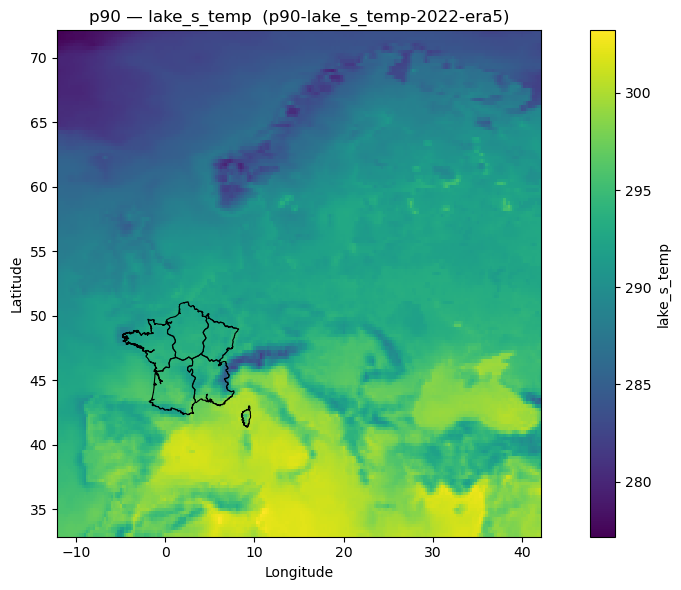

In [3]:
from compute_p90_cutout import plot_p90_heatmap

fig = plot_p90_heatmap(
    p90_path = pypsa_eur_root / "resources/2022-FR/2022-FR-nucl_dmg/p90-lake_s_temp-2022-era5.nc",
    regions_path = pypsa_eur_root / "resources/2022-FR/2022-FR-base/regions_onshore_base_s_5.geojson"
)
